# Session 2 — Multi-layer neural networks from scratch Plus Pytorch

**Goal:** Understand how multilayer neural networks are built from elementary operations before using a library such as PyTorch.

A two-layer neural-network (TLNN) may look like following:

<img src="two_layer_neural_network3.png" width="700">





## 0. Basic setup

We first import **NumPy** for matrix operations and **Matplotlib** for plotting. We also set a random seed so that the same random data and initial weights are produced each time the notebook is run.


In [1]:
# Import NumPy for arrays, random numbers, and matrix multiplication.
import numpy as np

# Import Matplotlib's plotting interface for visualizing data and training curves.
import matplotlib.pyplot as plt

# Fix the random seed so the results are reproducible each time the notebook is run.
np.random.seed(7)

# Set the default figure size so plots are readable in the notebook.
plt.rcParams["figure.figsize"] = (7, 4)

# Turn on grid lines by default to make plots easier to interpret.
plt.rcParams["axes.grid"] = True


## 1. Why add a hidden layer?

A single-layer neural-network (SLNN) model can only create a **linear regression model** in Regression problems, or a **linear decision boundary** in the classification problems. Many real patterns are curved or nonlinear. <span style="color:blue">A hidden layer transforms the inputs (which can also be termed as *original features*) into *new/learned features*, and the final layer combines those learned features into the final output</span>.



**The hidden layer is where the network gains nonlinear modeling power.**


## 2. Nonlinear regression dataset

The following code creates a **noisy sine curve**. A straight line cannot fit this shape well, so it is a good example for showing why a hidden layer is useful.


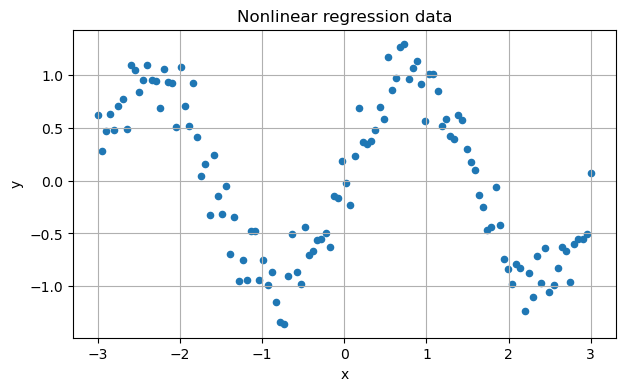

In [2]:
# Choose the number of training examples in the regression dataset.
N = 120

# Create 120 evenly spaced input values between -3 and 3 and reshape them into a column vector.
# -1 in dimensions mean to figure out this dimension automatically
Xr = np.linspace(-3, 3, N).reshape(-1, 1)

# Create noisy target values using a sine function plus Gaussian noise.
yr = np.sin(2 * Xr) + 0.2 * np.random.normal(size=(N, 1))

# Draw the input-output pairs as a scatter plot.
plt.scatter(Xr[:, 0], yr[:, 0], s=20)

# Add a descriptive title to the plot.
plt.title("Nonlinear regression data")

# Label the horizontal axis.
plt.xlabel("x")

# Label the vertical axis.
plt.ylabel("y")

# Display the plot.
plt.show()


## 3. Activation functions

Without a nonlinear activation function, stacking several linear layers still collapses into one big linear layer. <span style="color:blue">The activation function is therefore essential to model a non-linear relationship</span>.

There are different activation functions, such as Sigmoid, ReLU, tanh etc, each with its pros and cons.

In this notebook, **the hidden layer mostly uses `tanh` because its derivative is simple**



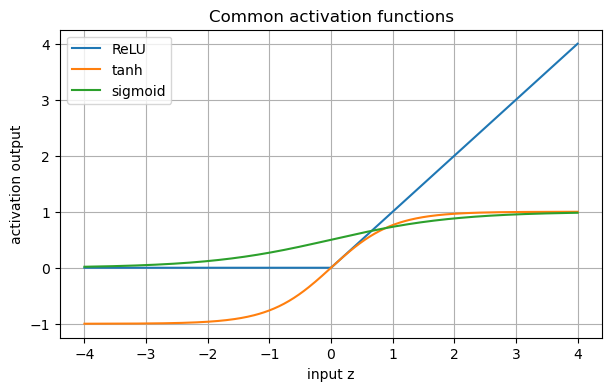

In [3]:
# Create many z-values so the activation curves appear smooth.
z = np.linspace(-4, 4, 300)

# Compute the ReLU activation for each z-value.
relu = np.maximum(0, z)

# Compute the tanh activation for each z-value.
tanh = np.tanh(z)

# Compute the sigmoid activation for each z-value.
sig = 1 / (1 + np.exp(-z))

# Plot the ReLU curve.
plt.plot(z, relu, label="ReLU")

# Plot the tanh curve.
plt.plot(z, tanh, label="tanh")

# Plot the sigmoid curve.
plt.plot(z, sig, label="sigmoid")

# Add a legend so each curve can be identified.
plt.legend()

# Add a descriptive plot title.
plt.title("Common activation functions")

# Label the input axis.
plt.xlabel("input z")

# Label the output axis.
plt.ylabel("activation output")

# Display the plot.
plt.show()


## 4. <span style="color:blue">Forward pass</span> vs. <span style="color:blue">Background pass</span> 

**Training** of a neural network is done in many iterations/epochs. Each iteration comprises of one *forward pass* and one *backward pass*

**Forward pass** = Perform output related computations going from left (input nodes) to right (output nodes) in a neural network <span style="color:red">architecture</span>. That is, the <span style="color:blue"> goal of forward pass is to calculate the network output (output will be continuous value in Regression or a label in classification) from its inputs using current set of weights</span>.

<img src="forward_pass2.png" width="700">

**Backward pass** = Perform gradient related computations going from right (output nodes) to left (input nodes) in a neural network architecture. That is, the <span style="color:blue"> goal of backward pass is to perform gradient based update of current set of weights</span>.

<img src="backward_pass2.png" width="700">

Backward pass is done via the **chain rule** which provides an easier way to calculate gradients of ALL(could be millions) of the Loss function with respect to the network parameters (weights and biases in each itertion) 

<img src="chain_rule.png" width="700">

Before we perform training of 2-layer network below, we re-iterate that <span style="color:blue">each iteration in training consists of one forward pass and one backward pass</span> through the network, as shown in the figure below:

<img src="training_loop.png" width="700">

## 5. Training of a Two-layer Neural-Network (TLNN) for Non-Linear Regression Problem

The code below trains the network from scratch. Every line is commented so that each operation can be connected to the forward or backward pass.

<span style="color:red"> **Task**: Observe the learned parameter values (W1, b1, W2, b2) printed in the cell below and do 1. comment on the size or the number of values given for each parameter, and 2. In Single-layer Neural Network based Regression, we could relate the learned parameter values (slope,intercept)  to the  true values (slope, intercept of the original linear model), do the same here for the non-linear model</span>


In [4]:
# Define a function that trains a two-layer neural network for regression.
def train_tlnn_regression(X, y, hidden=8, lr=0.03, epochs=3000):
    # Read the number of samples N and number of input features D from X.
    N, D = X.shape
    print(X.shape)
    print(yr.shape)

    # Initialize first-layer weights with shape (input_features, hidden_neurons).
    W1 = np.random.randn(D, hidden) * np.sqrt(1 / D)

    # Initialize first-layer bias with one bias value per hidden neuron.
    b1 = np.zeros((1, hidden))

    # Initialize second-layer weights with shape (hidden_neurons, output_neurons).
    W2 = np.random.randn(hidden, 1) * np.sqrt(1 / hidden)

    # Initialize the output-layer bias with one scalar value.
    b2 = np.zeros((1, 1))

    # Create a list to store the loss value at every epoch.
    losses = []

    # Repeat forward pass, backward pass, and parameter update many times.
    for epoch in range(epochs):
        
        # FORWARD PASS STARTS
        # Compute hidden pre-activation values z1 = XW1 + b1.
        z1 = X @ W1 + b1

        # Apply tanh activation to get hidden-layer outputs h.
        h = np.tanh(z1)

        # Compute the final prediction using the hidden features.
        y_hat = h @ W2 + b2

        # Compute prediction error for every training example.
        error = y_hat - y

        # Compute mean squared error over the whole batch.
        loss = np.mean(error ** 2)

        # Store the current loss so we can plot the learning curve later.
        losses.append(loss)

        
        # BACKWARD PASS STARTS
        # Compute gradient of MSE loss with respect to y_hat.
        dy = (2 / N) * error

        # Compute gradient of loss with respect to W2 using h as the input to layer 2.
        dW2 = h.T @ dy

        # Compute gradient of loss with respect to b2 by summing over all samples.
        db2 = np.sum(dy, axis=0, keepdims=True)

        # Propagate the gradient backward from output layer to hidden activations.
        dh = dy @ W2.T

        # Convert gradient through tanh using derivative 1 - tanh(z1)^2 = 1 - h^2.
        dz1 = dh * (1 - h ** 2)

        # Compute gradient of loss with respect to W1 using X as the input to layer 1.
        dW1 = X.T @ dz1

        # Compute gradient of loss with respect to b1 by summing over all samples.
        db1 = np.sum(dz1, axis=0, keepdims=True)

        
        # PARAMETER UPDATE STARTS
        # Update W1 by moving opposite to the gradient.
        W1 -= lr * dW1

        # Update b1 by moving opposite to the gradient.
        b1 -= lr * db1

        # Update W2 by moving opposite to the gradient.
        W2 -= lr * dW2

        # Update b2 by moving opposite to the gradient.
        b2 -= lr * db2

    # Store all learned parameters in a dictionary for later prediction.
    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

    # Return learned parameters and the history of losses.
    return params, np.array(losses)


# Train the regression network on the nonlinear sine dataset.
params_r, losses_r = train_tlnn_regression(Xr, yr, hidden=12, lr=0.03, epochs=3000)

# print all key-value pairs
#print(len(params_r))
for key, value in params_r.items():
    print(f"{key}:")
    print(value)
    print()        # blank line between entries

# Print the learned parameters
#print("Learned Parameters (W1, b1, W2, b2):", params_r(:,-1))

# Print the final mean squared error after training.
print("final MSE:", losses_r[-1])




(120, 1)
(120, 1)
W1:
[[-0.57928102 -1.56270562  0.6205247   0.63074429 -0.55706157  0.618472
   0.63040961  0.58530158  1.53647157  0.57065298 -1.54765571 -1.13630017]]

b1:
[[ 0.00024304  0.03296597 -0.00011515 -0.01874013 -0.00630464  0.00291513
  -0.01257189  0.00213302 -0.00548467  0.00444779  0.01904    -0.01876374]]

W2:
[[ 0.30418819]
 [-1.20163219]
 [-0.73644157]
 [-1.08779835]
 [ 0.37098119]
 [-0.69232017]
 [-1.09842675]
 [-0.39673847]
 [ 1.07755468]
 [-0.36998544]
 [-1.18578941]
 [-0.38209471]]

b2:
[[0.00499485]]

final MSE: 0.09436410671650809


## 7. Two-Layer Neural-Network Regression results

After training, the **network has learned a nonlinear curve**. The <span style="color:blue">loss curve should generally decrease if learning is stable.</span>

<span style="color:red"> **Task**: Analyze the impact of number of nodes in hidden layer by varying it and observing the impact on performance</span>

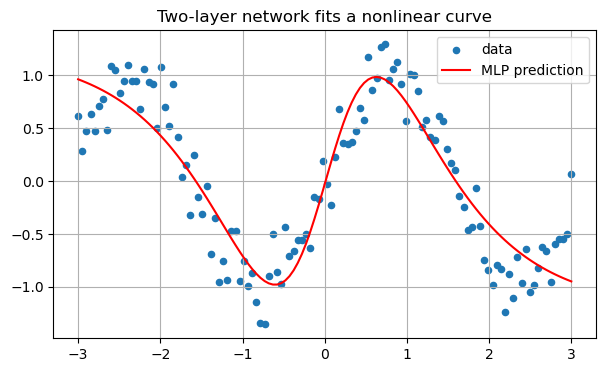

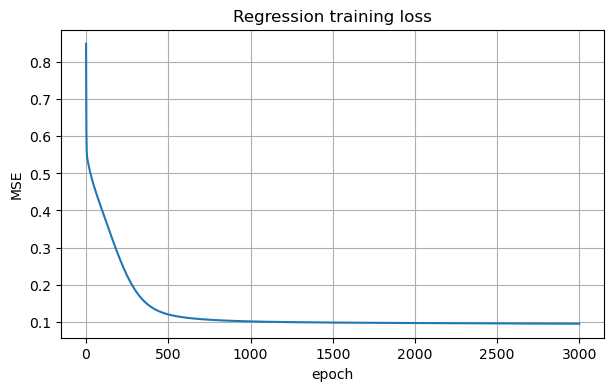

In [5]:

# Define a prediction function for the trained regression network.
def tlnn_regression_predict(X, params):
    # Compute hidden-layer activations using the learned first-layer parameters.
    h = np.tanh(X @ params["W1"] + params["b1"])

    # Compute and return the final regression prediction.
    return h @ params["W2"] + params["b2"]

# Use the trained regression model to predict y-values for the original inputs.
y_pred = tlnn_regression_predict(Xr, params_r)

# Plot the original noisy training data.
plt.scatter(Xr[:, 0], yr[:, 0], s=20, label="data")

# Plot the neural network's learned curve.
plt.plot(Xr[:, 0], y_pred[:, 0], label="MLP prediction", color="red")

# Add a legend to distinguish data points and model prediction.
plt.legend()

# Add a title describing the fitted curve.
plt.title("Two-layer network fits a nonlinear curve")

# Display the fitted curve plot.
plt.show()

# Plot the loss values over training epochs.
plt.plot(losses_r)

# Label the horizontal axis as epoch number.
plt.xlabel("epoch")

# Label the vertical axis as mean squared error.
plt.ylabel("MSE")

# Add a title describing the training curve.
plt.title("Regression training loss")

# Display the loss curve.
plt.show()


## 8. <span style="color:blue">Nonlinear</span> classification data

Now we create a **circle-like dataset**. <span style="color:blue">Points inside the circle are **class 0** and points outside the circle are **class 1**</span>. 

<span style="color:red">A straight line cannot separate these classes well</span>. Hence, a **non-linear boundary needed**


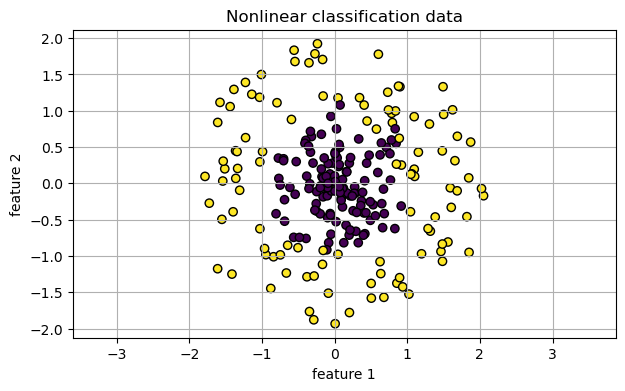

In [6]:
# Choose the number of examples in the classification dataset.
N = 240

# Randomly sample angles from 0 to 2π for points around a circle.
angles = np.random.uniform(0, 2 * np.pi, N)

# Randomly sample radii from 0 to 2 for points at different distances from the center.
radius = np.random.uniform(0, 2, N)

# Convert polar coordinates into TWO CARTESIAN FEATURES x1 and x2.
Xc = np.c_[radius * np.cos(angles), radius * np.sin(angles)]

# Assign class 1 to points outside radius 1 and class 0 to points inside radius 1.
yc = (radius > 1.0).astype(float).reshape(-1, 1)

# Add small Gaussian noise so the data is more realistic.
Xc += np.random.normal(0, 0.08, size=Xc.shape)

# Plot the classification data using color to represent the class label.
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc[:, 0], edgecolor="k")

# Add a title explaining the plot.
plt.title("Nonlinear classification data")

# Label the first feature axis.
plt.xlabel("feature 1")

# Label the second feature axis.
plt.ylabel("feature 2")

# Keep equal axis scaling so the circular structure looks circular.
plt.axis("equal")

# Display the plot.
plt.show()


## 9. Two-layer neural-network based classification

For *binary* classification, <span style="color:blue">the network *ends* with a sigmoid activation</span>:

$$
z_2=hW_2+b_2, \qquad p=\sigma(z_2)
$$

where $p$ is the estimated probability of class 1. given by p=P(y=1\mid x)

Training a neural network for the classification problem with *Cross-Entropy* loss function is a better option than using the loss function of mean-square error (MSE) as it penalized confident mistakes more severely thereby improving overall classification performance. Binary cross-entropy loss function is given as:

$$
L=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

Using cross-entropy loss function with Sigmoid activation function results in a simplified gradient:

$$
dz_2=\frac{\partial L}{\partial z_2}=\frac{p-y}{N}
$$

So the output-layer error is simply **prediction minus truth**, scaled by the batch size.

<svg width="850" height="180" xmlns="http://www.w3.org/2000/svg">
  <defs><marker id="arrow4" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto"><path d="M0,0 L0,6 L9,3 z" fill="#555"/></marker></defs>
  <rect x="20" y="55" width="80" height="55" rx="8" fill="#e8f2ff" stroke="#4c78a8"/><text x="60" y="88" text-anchor="middle" font-size="15">X</text>
  <line x1="100" y1="82" x2="155" y2="82" stroke="#555" marker-end="url(#arrow4)"/>
  <rect x="155" y="55" width="120" height="55" rx="8" fill="#fff4e6" stroke="#f58518"/><text x="215" y="76" text-anchor="middle" font-size="14">hidden</text><text x="215" y="96" text-anchor="middle" font-size="13">h=tanh(z₁)</text>
  <line x1="275" y1="82" x2="330" y2="82" stroke="#555" marker-end="url(#arrow4)"/>
  <rect x="330" y="55" width="120" height="55" rx="8" fill="#f2e9ff" stroke="#8e6bbd"/><text x="390" y="76" text-anchor="middle" font-size="14">score</text><text x="390" y="96" text-anchor="middle" font-size="13">z₂=hW₂+b₂</text>
  <line x1="450" y1="82" x2="505" y2="82" stroke="#555" marker-end="url(#arrow4)"/>
  <rect x="505" y="55" width="115" height="55" rx="8" fill="#eaf7ea" stroke="#54a24b"/><text x="562" y="76" text-anchor="middle" font-size="14">sigmoid</text><text x="562" y="96" text-anchor="middle" font-size="13">p=σ(z₂)</text>
  <line x1="620" y1="82" x2="675" y2="82" stroke="#555" marker-end="url(#arrow4)"/>
  <rect x="675" y="55" width="135" height="55" rx="8" fill="#fff0f0" stroke="#e45756"/><text x="742" y="76" text-anchor="middle" font-size="14">BCE loss</text><text x="742" y="96" text-anchor="middle" font-size="13">dz₂=(p-y)/N</text>
</svg>


## 10. Two-layer Neural-Network based classifier from elementary operations

This is the *classifier* version of the two-layer network that we used above for regression. The <span style="color:blue">goal in regression is to predict a continuous value</span> e.g. predict the temperature tomorrow, whereas the <span style="color:blue">goal in a classifier is to predict a label/class</span> for the inputs e.g. whether the input image is that of a cat or a dog. In order <span style="color:blue">to generate a class label at the output, the use of a **Sigmoid activation function in the output layer** produces a probability</span>. For the binary classification problem this <span style="color:blue">output probability can be converted into class-labels by using a **probabilility threshold of 0.5**</span> i.e. the inputs resulting in an output probability of less than 0.5 belong to class 0, and the inputs with an output probability greater than 0.5 belong to class 1.


In [8]:
# Define the sigmoid function that maps any real-valued score into the interval (0, 1).
def sigmoid(z):
    # Return the logistic transformation of z.
    return 1 / (1 + np.exp(-z))

# Define binary cross-entropy loss for predicted probabilities and true labels.
def bce(p, y, eps=1e-9):
    # Clip probabilities to avoid log(0), which is undefined.
    p = np.clip(p, eps, 1 - eps)

    # Return the mean binary cross-entropy over all samples.
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# Define a function that trains a two-layer neural network classifier.
def train_mlp_classifier(X, y, hidden=12, lr=0.1, epochs=3000):
    # Read the number of samples N and input features D.
    N, D = X.shape

    # Initialize first-layer weights for mapping inputs into hidden neurons.
    W1 = np.random.randn(D, hidden) * np.sqrt(2 / D)

    # Initialize first-layer biases with one bias per hidden neuron.
    b1 = np.zeros((1, hidden))

    # Initialize second-layer weights for mapping hidden features into one output score.
    W2 = np.random.randn(hidden, 1) * np.sqrt(2 / hidden)

    # Initialize the output-layer bias as one scalar value.
    b2 = np.zeros((1, 1))

    # Create a list to store binary cross-entropy loss values.
    losses = []

    # Repeat training for the requested number of epochs.
    for epoch in range(epochs):
        #FORWARD PASS
        # Compute hidden-layer pre-activation scores.
        z1 = X @ W1 + b1

        # Apply tanh to create nonlinear hidden features.
        h = np.tanh(z1)

        # Compute the output-layer score before sigmoid.
        z2 = h @ W2 + b2

        # Convert the output score into a probability of class 1.
        p = sigmoid(z2)

        # Compute binary cross-entropy loss for the current predictions.
        loss = bce(p, y)

        # Store the loss value for later plotting.
        losses.append(loss)

        # BACKWARD PASS
        # Use the sigmoid plus BCE simplification for the output gradient.
        dz2 = (p - y) / N

        # Compute the gradient of loss with respect to W2.
        dW2 = h.T @ dz2

        # Compute the gradient of loss with respect to b2.
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Propagate the gradient back into the hidden layer activations.
        dh = dz2 @ W2.T

        # Convert hidden activation gradient into hidden pre-activation gradient.
        dz1 = dh * (1 - h ** 2)

        # Compute the gradient of loss with respect to W1.
        dW1 = X.T @ dz1

        # Compute the gradient of loss with respect to b1.
        db1 = np.sum(dz1, axis=0, keepdims=True)

        #PARAMETERS UPDATION
        # Update first-layer weights using gradient descent.
        W1 -= lr * dW1

        # Update first-layer biases using gradient descent.
        b1 -= lr * db1

        # Update second-layer weights using gradient descent.
        W2 -= lr * dW2

        # Update output-layer bias using gradient descent.
        b2 -= lr * db2

    # Return learned parameters and training loss history.
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}, np.array(losses)

# Define a function that outputs predicted probabilities from the trained classifier.
def mlp_classifier_predict_proba(X, params):
    # Compute hidden features from inputs and first-layer parameters.
    h = np.tanh(X @ params["W1"] + params["b1"])

    # Compute output scores and apply sigmoid to get probabilities.
    return sigmoid(h @ params["W2"] + params["b2"])

# Train the classifier on the circular dataset.
params_c, losses_c = train_mlp_classifier(Xc, yc, hidden=16, lr=0.15, epochs=3000)

# Compute predicted probabilities for the training data.
probs = mlp_classifier_predict_proba(Xc, params_c)

# Convert probabilities to class labels using threshold 0.5 and compute accuracy.
acc = np.mean((probs >= 0.5) == yc)

# Print final classification accuracy and final BCE loss.
print("accuracy:", acc, "final BCE:", losses_c[-1])



accuracy: 0.9666666666666667 final BCE: 0.08989916460234908


## 11. Decision boundary and training loss

<span style="color:blue">A two-layer network can learn a curved decision boundary</span> because the hidden layer has transformed the input space. The **contour line where \(p=0.5\) is the classification boundary** is shown below for our small demo dataset

<span style="color:red">**Task**: Vary the value of the parameters 'no. of hidden nodes' and 'threshold' and analyze the impact on performance (Use some extreme values as well)</span>


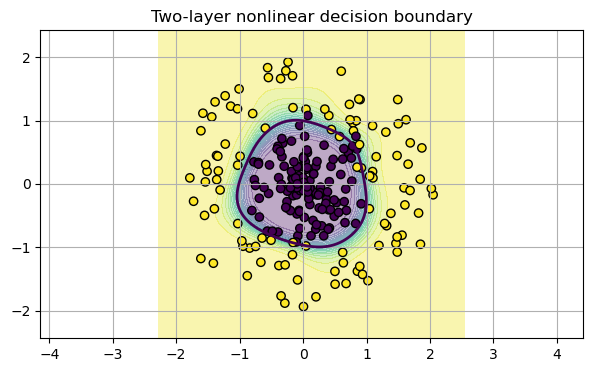

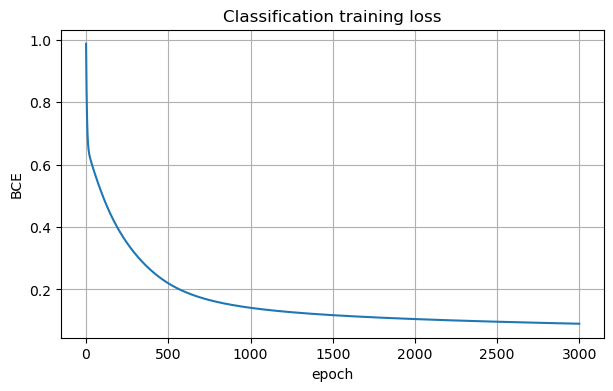

In [9]:
# Define a helper function to visualize the classifier's decision boundary.
def plot_boundary_mlp(X, y, params):
    # Compute the left and right limits of the plot.
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5

    # Compute the bottom and top limits of the plot.
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a dense grid of x and y coordinates for evaluating the model.
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

    # Combine the grid coordinates into feature pairs.
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict class-1 probabilities for every point on the grid.
    probs = mlp_classifier_predict_proba(grid, params).reshape(xx.shape)

    # Draw filled contours showing the probability surface.
    plt.contourf(xx, yy, probs, levels=20, alpha=0.35)

    # Draw the p=0.5 contour, which is the decision boundary.
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

    # Draw the original training examples on top of the boundary.
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], edgecolor="k")

    # Add a title explaining the plot.
    plt.title("Two-layer nonlinear decision boundary")

    # Use equal scaling so distances are not visually distorted.
    plt.axis("equal")

    # Display the decision-boundary plot.
    plt.show()

# Plot the learned decision boundary for the trained classifier.
plot_boundary_mlp(Xc, yc, params_c)

# Plot the classification loss curve across epochs.
plt.plot(losses_c)

# Label the horizontal axis as epoch number.
plt.xlabel("epoch")

# Label the vertical axis as binary cross-entropy.
plt.ylabel("BCE")

# Add a title explaining the plot.
plt.title("Classification training loss")

# Display the loss curve.
plt.show()


## 12. Shapes in forward and backward passes

<span style="color:blue">Keeping track of shapes/sizes of the arrays/tensors representing inputs, outputs and parameter is one of the most important debugging skills</span> when implementing neural networks from scratch.

For a batch of \(N\) examples, \(D\) input features, and \(H\) hidden neurons:

 Quantity | Shape |
|---|---|
| Input data  \(X\) | \((N,D)\) | 
| Input-to-hidden weights \(W_1\) | \((D,H)\) | 
| Hidden biases\(b_1\) | \((1,H)\) | 
| Hidden pre-activation \(z_1\) | \((N,H)\) | 
| Hidden activation \(h\) | \((N,H)\) | 
| Hidden-to-output weights \(W_2\) | \((H,1)\) | 
| Output bias \(b_2\) | \((1,1)\) | 
| Predicted probabilities \(p\) | \((N,1)\) | 


In [10]:
# Extract the learned first-layer weight matrix.
W1 = params_c["W1"]

# Extract the learned first-layer bias vector.
b1 = params_c["b1"]

# Extract the learned second-layer weight matrix.
W2 = params_c["W2"]

# Extract the learned second-layer bias value.
b2 = params_c["b2"]

# Compute hidden pre-activations for the classification dataset.
z1 = Xc @ W1 + b1

# Compute hidden activations using tanh.
h = np.tanh(z1)

# Compute output pre-activation scores.
z2 = h @ W2 + b2

# Compute output probabilities using sigmoid.
p = sigmoid(z2)

# Print the input data shape.
print("Xc shape:", Xc.shape)

# Print the first-layer weight shape.
print("W1 shape:", W1.shape)

# Print the first-layer bias shape.
print("b1 shape:", b1.shape)

# Print the hidden pre-activation shape.
print("z1 shape:", z1.shape)

# Print the hidden activation shape.
print("h shape:", h.shape)

# Print the second-layer weight shape.
print("W2 shape:", W2.shape)

# Print the second-layer bias shape.
print("b2 shape:", b2.shape)

# Print the output score shape.
print("z2 shape:", z2.shape)

# Print the probability output shape.
print("p shape:", p.shape)


Xc shape: (240, 2)
W1 shape: (2, 16)
b1 shape: (1, 16)
z1 shape: (240, 16)
h shape: (240, 16)
W2 shape: (16, 1)
b2 shape: (1, 1)
z2 shape: (240, 1)
p shape: (240, 1)


## 13. Interactive experiment

More hidden neurons can model more complex functions, but they can also overfit. A larger learning rate can speed up training, but if it is too large the loss may become unstable.

<span style="color:red">**Task**: Vary the value of the parameters 'no. of hidden nodes', 'learning rate' and 'epochs'` using the sliders below and analyze the impact of their increase/decrease on the performance </span> 

In [12]:
# Start a try block because ipywidgets may not be installed in every environment.
try:
    # Import interact for creating interactive controls in a notebook.
    from ipywidgets import interact

    # Import integer and logarithmic sliders for controlling model settings.
    from ipywidgets import IntSlider, FloatLogSlider

    # Define the experiment function that will be called whenever a slider changes.
    def experiment(hidden=8, lr=0.1, epochs=1000):
        # Train a new classifier using the selected hidden size, learning rate, and epochs.
        params, losses = train_mlp_classifier(Xc, yc, hidden=hidden, lr=lr, epochs=epochs)

        # Predict probabilities for the training data.
        probs = mlp_classifier_predict_proba(Xc, params)

        # Convert probabilities to class labels and compute accuracy.
        acc = np.mean((probs >= 0.5) == yc)

        # Print the selected settings and final results.
        print(f"hidden={hidden}, lr={lr:.4f}, epochs={epochs}, accuracy={acc:.3f}, final loss={losses[-1]:.3f}")

        # Plot the decision boundary for this experiment.
        plot_boundary_mlp(Xc, yc, params)

        # Plot the loss curve for this experiment.
        plt.plot(losses)

        # Add a title to the loss curve.
        plt.title("Loss curve")

        # Label the horizontal axis.
        plt.xlabel("epoch")

        # Label the vertical axis.
        plt.ylabel("BCE")

        # Display the loss plot.
        plt.show()

    # Create interactive sliders for hidden units, learning rate, and epochs.
    interact(
        # Pass the experiment function to interact.
        experiment,
        # Create a slider for the number of hidden neurons.
        hidden=IntSlider(value=8, min=2, max=32, step=2),
        # Create a logarithmic slider for the learning rate.
        lr=FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.1),
        # Create a slider for the number of training epochs.
        epochs=IntSlider(value=1000, min=100, max=3000, step=100)
    )

# Catch any error, usually because ipywidgets is not installed.
except Exception:
    # Print a helpful message when the interactive widget cannot be used.
    print("Install ipywidgets to use interactive sliders.")


interactive(children=(IntSlider(value=8, description='hidden', max=32, min=2, step=2), FloatLogSlider(value=0.…

## 14. Why <span style="color:red">building multilayer networks from scratch is not a good idea </span> in practice

Writing a small neural network from scratch is excellent for learning, but it is not the best way to build real models.

**Main reasons**:

- **Manual gradients are error-prone.** One wrong transpose or missing factor of \(1/N\) can silently break training.
- **Numerical stability matters.** Losses, such as binary cross-entropy, can have very small values and hence can cause numerical accuracy issues.
- **Performance matters.** The performance of a code written using only basic Python/NumPy may not be optimized in performance 
- **Scalability matters.** Real networks may have millions or billions of parameters, and manual coding may be too complex/time-consuming

The solution to above problems can be obtained via <span style="color:blue">making use of specialized Python *Libraries*</span>. **A library is a collection of reusable code that provides ready-made solutions to common programming tasks, allowing developers to build applications more quickly and reliably**. Some well-known Python libraries for building and training deep neural networks are TensorFlow (originally developed by Google), Keras (originally developed as an independent open-source project and now integrated into TensorFlow), and PyTorch (originally developed by Meta, formerly Facebook).

Most developers use these libraries to develop deep-learning based solutions. Their use comes with many advantages, such as, **gradients get computed automatically**, so you focus on the model and data. Also, Libraries implement stable versions of losses and use optimized CPU/GPU kernels instead of slow Python/NumPy loops.

<span style="color:blue">Let us make use of the Pytorch library to build a multi-layer neural network</span>


## 15. Building a Neural-network using a Python Library, e.g. PyTorch



The code below makes use of Pytorch to implement a classifier, similar to the one built above manually. The <span style="color:blue">PyTorch version is much shorter</span>. Figure below shows **Pytorch *objects* and *functions*** used for implementing different aspects of a neural-network

It is written inside a `try/except` block so the notebook still runs even if PyTorch is not installed. A figure explaining important code elements with the building of different aspects of neural network is also shown below:
<img src="pytorch_functions_nn3.png" width="700">






PyTorch accuracy: 0.9958333373069763 final loss: 0.02040756307542324


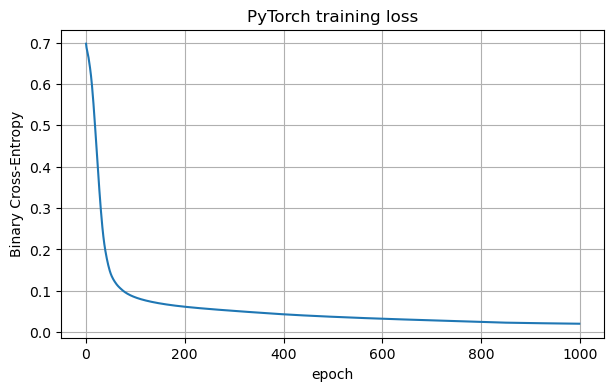

In [21]:
# Start a try block because PyTorch may not be installed in every environment.
try:
    # Import PyTorch for tensor operations and automatic differentiation.
    import torch

    # Import torch.nn for neural-network layers and loss functions.
    import torch.nn as nn

    # Import torch.optim for optimization algorithms such as SGD and Adam.
    import torch.optim as optim

    # Convert NumPy input data into a PyTorch float tensor.
    X_tensor = torch.tensor(Xc, dtype=torch.float32)

    # Convert NumPy labels into a PyTorch float tensor.
    y_tensor = torch.tensor(yc, dtype=torch.float32)

    # Define a small two-layer neural network using PyTorch's Sequential container.
    torch_model = nn.Sequential(
        # Create a fully connected input-to-hidden layer.
        nn.Linear(2, 16),
        # Apply tanh activation after the hidden linear layer.
        nn.Tanh(),
        # Create a fully connected hidden-to-output layer.
        nn.Linear(16, 1)
    )

    # Use BCEWithLogitsLoss because it combines sigmoid and BCE in a numerically stable way.
    loss_fn = nn.BCEWithLogitsLoss()

    # Use Adam optimizer to update the model parameters.
    optimizer = optim.Adam(torch_model.parameters(), lr=0.03)

     # Create a list to store losses across different iterations/epochs
    loss_history = []

    # Train the PyTorch model for a modest number of epochs.
    for epoch in range(1000):
        # Reset old gradients before computing new gradients.
        optimizer.zero_grad()

        # Compute raw output scores, also called logits.
        logits = torch_model(X_tensor)

        # Compute binary cross-entropy loss from logits and labels.
        loss = loss_fn(logits, y_tensor)

        # Store the loss value for later plotting.
        loss_history.append(loss.item())

        # Automatically compute gradients for all trainable parameters.
        loss.backward()

        # Update all trainable parameters using the optimizer.
        optimizer.step()

    # Disable gradient tracking because we only want to evaluate the model now.
    with torch.no_grad():
        # Convert logits into probabilities using sigmoid.
        torch_probs = torch.sigmoid(torch_model(X_tensor))

        # Convert probabilities into class predictions using threshold 0.5.
        torch_preds = (torch_probs >= 0.5).float()

        # Compute classification accuracy.
        torch_acc = (torch_preds == y_tensor).float().mean().item()

    # Print PyTorch model accuracy and final loss.
    print("PyTorch accuracy:", torch_acc, "final loss:", loss.item())

# Catch any error, usually because PyTorch is not installed.
except Exception as e:
    # Print a helpful message rather than stopping the whole notebook.
    print("PyTorch section skipped because PyTorch is not available or an error occurred:", e)

# Plot the training loss across different iterations/epochs
plt.plot(loss_history)

plt.xlabel("epoch")

plt.ylabel("Binary Cross-Entropy")

plt.title("PyTorch training loss")

plt.grid(True)

plt.show()

## 16. Decision boundary and training loss for Pytorch Neural-Network

As we did for the two-layer neural-network built from scratch, we plot below the **decision boundary** and training-loss profile for the neural-netowrk built via Pytorch

<span style="color:red">**Task**: Compare the accuracy of the *Pytorch NN* with that of the *Numpy Neural Network*. Try to use same netowrk parameters for both and see if the performance becomes exactly same or not.

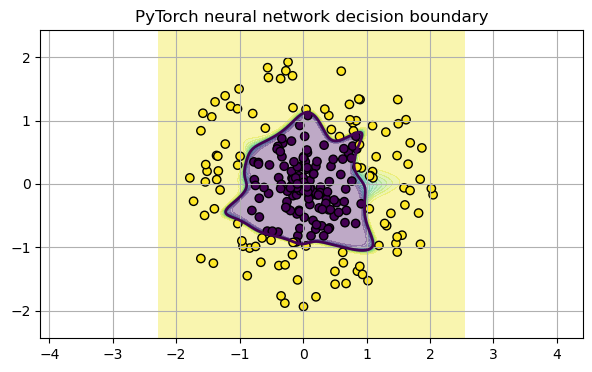

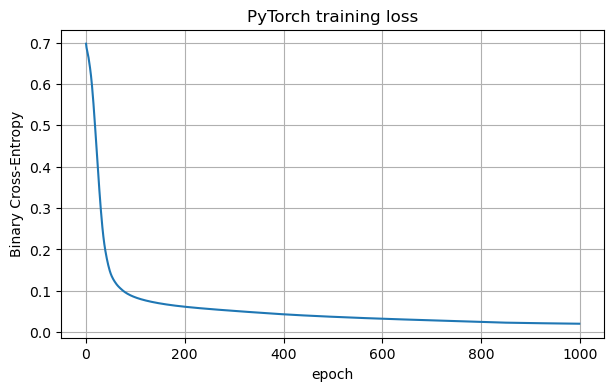

In [22]:
# Define a helper function to visualize the PyTorch classifier's decision boundary.
def plot_boundary_torch(X, y, model):

    # Compute the left and right limits of the plot.
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5

    # Compute the bottom and top limits of the plot.
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a dense grid of points.
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    # Convert the grid into feature vectors.
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Convert the grid to a PyTorch tensor.
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    # Disable gradient tracking during prediction.
    with torch.no_grad():

        # Compute logits.
        logits = model(grid_tensor)

        # Convert logits into probabilities.
        probs = torch.sigmoid(logits)

    # Convert probabilities back to NumPy.
    probs = probs.numpy().reshape(xx.shape)

    # Draw the probability surface.
    plt.contourf(xx, yy, probs, levels=20, alpha=0.35)

    # Draw the decision boundary.
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

    # Draw the training examples.
    plt.scatter(X[:,0], X[:,1], c=y[:,0], edgecolor="k")

    plt.title("PyTorch neural network decision boundary")

    plt.axis("equal")

    plt.show()

# Plot the decision boundary
plot_boundary_torch(Xc, yc, torch_model)

# Plot the training loss across different iterations/epochs
plt.plot(loss_history)

plt.xlabel("epoch")

plt.ylabel("Binary Cross-Entropy")

plt.title("PyTorch training loss")

plt.grid(True)

plt.show()

## 17. From-scratch code vs PyTorch code

The two approaches implement the same learning idea, but at different abstraction levels.

| Aspect | From scratch with NumPy | PyTorch |
|---|---|---|
| <span style="color:blue">Forward pass</span> | You write every matrix operation | You define layers and call the model |
| <span style="color:blue">Backward pass</span> | You derive and code gradients manually | `loss.backward()` computes gradients |
| <span style="color:blue">Parameter update</span> | You manually subtract gradients | Optimizer updates parameters |
| <span style="color:blue">Stability</span> | You must handle numerical issues | Stable losses are built in |
| <span style="color:blue">Best use</span> | Learning and teaching | Real experiments and research |




## 18. Key takeaways of Session 2: 

- **Multi-layer Neural-Networks** <span style="color:blue">connect many *layers* of neurons/nodes in a chain like manner</span>, with each layer having one or more nodes.
-  As for single-layer neural-networks, <span style="color:blue">training of multi-layer netorks involve repeated loops of *forward* passes, losses calculation, *backward* passes, and parameter updates</span>.
- The **performance of a neural-network, in general, improves with an increase in its depth (no. of layers)** because of enhanced ability to model complex relationships albeit with increased complexity.
- Building multi-layer neural networks from scratch is a cumbersome process and <span style="color:blue">developers mostly use Python libraries such as Pytorch</span> to build such networks


## 19. Extra exercises

1. Add noise to the labels. What happens to the loss and boundary?



